In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_excel("RFL_pred_dataset.xlsx")

In [3]:
df

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin,Predicted_RFL_Att
0,8.480261,9.694687,15.930662,17.504117,15.322833,2959.931772,73500000000,0.000000,0.000000,0.000000,...,21.173420,10,50251.391340,52745.193251,47764.908850,84.421790,0.057545,0.462188,0.055872,6.722068
1,3.511600,11.336494,4.884168,5.139645,4.514668,2018.767588,73500000000,0.000000,0.000000,0.000000,...,15.251449,11,19554.715500,19854.670076,18626.944712,95.589421,0.000000,1.720969,0.000000,11.581648
2,6.058910,10.266708,21.586978,22.967831,20.407107,2956.858380,73500000000,0.000000,0.000000,0.000000,...,26.583940,22,15287.325520,16669.585430,14027.718822,91.561005,0.676281,1.113779,0.615111,10.292379
3,6.593463,11.443969,4.074320,4.186823,3.917267,4818.176068,73500000000,0.000000,0.000000,0.000000,...,2.434717,12,25159.573780,25252.272628,24293.881091,32.930082,0.110289,0.175660,0.105458,11.454311
4,6.801351,8.726055,17.840132,19.071630,16.777477,2955.199128,73500000000,0.000000,0.000000,0.000000,...,24.685737,3,30345.736030,33269.672010,28258.151377,95.750686,0.221128,1.290878,0.210291,9.443620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42859,5.450631,13.686893,5.437567,5.841524,5.431575,4825.841905,83500000000,16.957986,18.215495,15.876605,...,5.462535,5,27589.122520,29515.848890,27059.715033,91.460178,0.000000,3.339221,0.000000,13.472265
42860,8.562129,5.726912,18.646348,20.202120,17.269297,2115.649872,73500000000,27.278849,28.111408,25.549803,...,20.526191,22,12247.857120,13280.793041,12142.272075,100.335047,0.692477,1.564934,0.668976,5.772724
42861,5.831768,13.166719,11.384310,11.686584,11.054054,2018.153150,73500000000,174.912616,188.515642,172.608997,...,13.906865,0,7879.930898,8428.066276,7303.756801,106.176817,0.092167,0.170267,0.083516,13.076798
42862,4.798019,13.244202,5.938114,6.182977,5.461478,4819.435242,73500000000,5.954184,5.964829,5.790368,...,6.373556,15,74106.624310,77990.816742,72244.986530,98.457790,0.039269,0.174291,0.037609,13.118065


In [4]:
def recursive_feature_elimination(df, target_col, drop_col=None):
    X = df.drop(columns=[target_col])
    if drop_col and drop_col in X.columns:
        X = X.drop(columns=[drop_col])
    y = df[target_col]

    S = list(X.columns)
    R = []

    while len(S) > 1:
        model = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True, bootstrap=True)
        model.fit(X[S], y)
        y_pred = model.predict(X[S])

        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        importances = model.feature_importances_
        least_idx = np.argmin(importances)
        R.append((S[least_idx], rmse, r2))
        S.pop(least_idx)

    # Final feature
    model.fit(X[S], y)
    y_pred = model.predict(X[S])
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    R.append((S[0], rmse, r2))

    return pd.DataFrame(R, columns=["Feature", "RMSE", "R2"])


In [5]:
def plot_feature_elimination(result_df, title, green_line_feature=None):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.grid(True)

    ax1.set_xlabel("Features removed (in order)")
    ax1.set_ylabel("RMSE (dB)", color="tab:blue")
    ax1.plot(result_df['Feature'], result_df['RMSE'], color="tab:blue")
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_xticks(range(len(result_df['Feature'])))
    ax1.set_xticklabels(result_df['Feature'], rotation=90)

    ax2 = ax1.twinx()
    ax2.set_ylabel("R² Score", color="tab:orange")
    ax2.plot(result_df['Feature'], result_df['R2'], color="tab:orange")
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    if green_line_feature in result_df['Feature'].values:
        idx = result_df[result_df['Feature'] == green_line_feature].index[0]
        ax1.axvline(x=idx, color='green', linestyle='dotted', linewidth=2)

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [6]:
# === Run for RFL_Att ===
rfl_result = recursive_feature_elimination(df, target_col='FSO_Att', drop_col='RFL_Att')

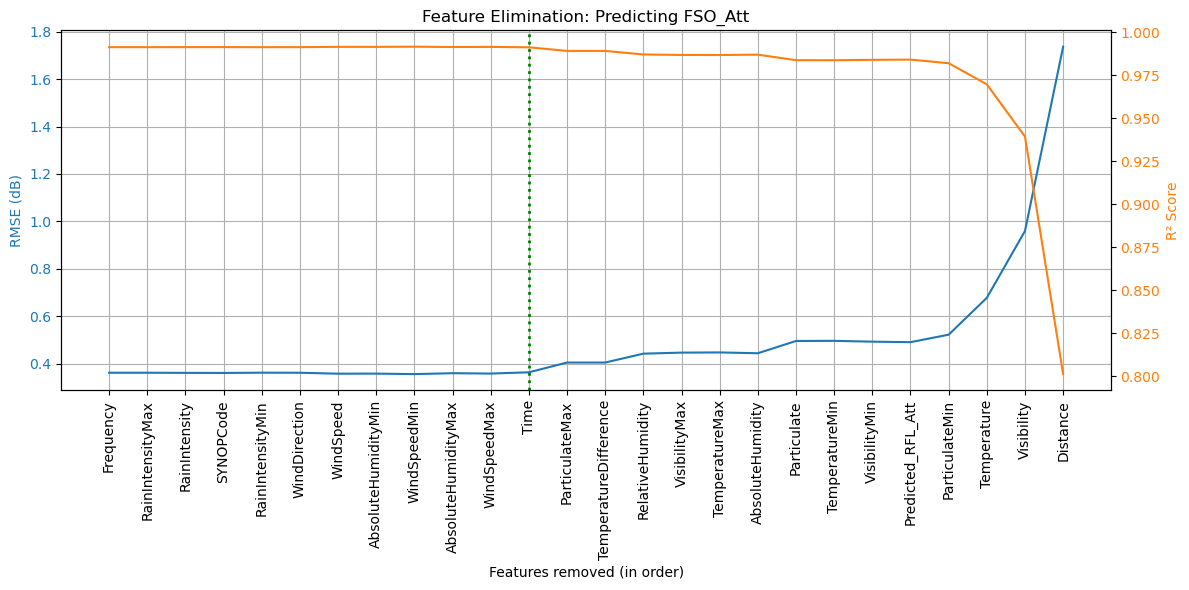

In [7]:
plot_feature_elimination(rfl_result, "Feature Elimination: Predicting FSO_Att", green_line_feature="Time")

In [77]:
selected_features = [
    'Distance', 'Visibility', 'Temperature', 'ParticulateMin', 'Predicted_RFL_Att',
    'VisibiltyMin', 'TemperatureMin', 'Particulate', 'TemperatureMax',
    'AbsoluteHumidity', 'VisibilityMax', 'RelativeHumidity','TemperatureDifference', 'ParticulateMax', 'Time', 'FSO_Att'
]

# Filter only the selected features (if they exist in the dataset)
filtered_df = df[[col for col in selected_features if col in df.columns]]

In [79]:
filtered_df

,Distance,Visibility,Temperature,ParticulateMin,Predicted_RFL_Att,TemperatureMin,Particulate,TemperatureMax,AbsoluteHumidity,VisibilityMax,RelativeHumidity,TemperatureDifference,ParticulateMax,Time,FSO_Att
0,2959.931772,50251.391340,22.384038,0.000000,6.722068,21.173420,0.000000,23.615676,15.930662,52745.193251,80.291130,0.000,0.000000,10,8.480261
1,2018.767588,19554.715500,15.593858,0.000000,11.581648,15.251449,0.000000,16.687616,4.884168,19854.670076,36.754752,3.630,0.000000,11,3.511600
2,2956.858380,15287.325520,27.592859,0.000000,10.292379,26.583940,0.000000,28.518049,21.586978,16669.585430,81.129278,0.250,0.000000,22,6.058910
3,4818.176068,25159.573780,2.632763,0.000000,11.454311,2.434717,0.000000,2.824572,4.074320,25252.272628,70.212589,0.225,0.000000,12,6.593463
4,2955.199128,30345.736030,27.080075,0.000000,9.443620,24.685737,0.000000,29.207603,17.840132,33269.672010,68.977211,0.020,0.000000,3,6.801351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42859,4825.841905,27589.122520,5.722957,15.876605,13.472265,5.462535,16.957986,5.817576,5.437567,29515.848890,76.290310,-0.200,18.215495,5,5.450631
42860,2115.649872,12247.857120,22.057799,25.549803,5.772724,20.526191,27.278849,23.635898,18.646348,13280.793041,95.759465,-0.320,28.111408,22,8.562129
42861,2018.153150,7879.930898,14.982220,172.608997,13.076798,13.906865,174.912616,15.285942,11.384310,8428.066276,88.914893,0.010,188.515642,0,5.831768
42862,4819.435242,74106.624310,6.939353,5.790368,13.118065,6.373556,5.954184,7.448264,5.938114,77990.816742,76.946078,-0.400,5.964829,15,4.798019


In [119]:
X = filtered_df.drop(columns=["FSO_Att"])
y = filtered_df["FSO_Att"]

In [121]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [123]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [2],
    'max_features': ['sqrt']
}

In [127]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [129]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'max_features': ['sqrt'],
                         'min_samples_split': [2], 'n_estimators': [50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [131]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}


In [133]:
best_model_1 = grid_search.best_estimator_
best_model_1.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', random_state=42)

In [135]:
y_train_pred = best_model_1.predict(X_train)
y_val_pred = best_model_1.predict(X_val)

In [137]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

In [139]:
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)

In [141]:
print(f"Training RMSE: {rmse_train:.4f}, Validation RMSE: {rmse_val:.4f}")
print(f"Training R²: {r2_train:.4f}, Validation R²: {r2_val:.4f}")

Training RMSE: 0.3846, Validation RMSE: 1.0722
Training R²: 0.9902, Validation R²: 0.9270


In [143]:
test_df = pd.read_excel('test_RFL_dataset_with_predictions.xlsx')

In [ ]:
#test_df

In [145]:
filtered_test_df = test_df[[col for col in selected_features if col in test_df.columns]]

In [ ]:
#filtered_test_df

In [147]:
X_test = filtered_test_df.drop(columns=["FSO_Att"])
y_test = filtered_test_df["FSO_Att"]

In [149]:
X_test

,Distance,Visibility,Temperature,ParticulateMin,Predicted_RFL_Att,TemperatureMin,Particulate,TemperatureMax,AbsoluteHumidity,VisibilityMax,RelativeHumidity,TemperatureDifference,ParticulateMax,Time
0,2961.886251,45857.443250,19.365744,0.000000,5.516930,17.557490,0.000000,19.979123,14.682099,48768.845558,88.198299,0.480,0.000000,21
1,2585.229227,36284.477600,19.022865,0.000000,12.615674,17.639011,0.000000,19.562956,7.858811,37503.198582,48.173038,1.070,0.000000,12
2,2958.820370,64350.111100,17.204336,0.000000,4.015647,15.877571,0.000000,18.524791,9.057397,64384.177940,61.857117,-0.600,0.000000,13
3,4820.483790,74995.192040,6.002452,0.000000,11.296617,5.436820,0.000000,6.267305,3.647547,78609.932555,50.246017,-0.635,0.000000,12
4,4826.974011,5322.886654,6.362073,0.000000,12.456611,5.813281,0.000000,6.711993,7.059999,5664.386291,94.991598,-0.100,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27412,2963.246753,21916.369070,25.181965,15.426239,9.874434,23.820605,16.180712,25.334012,19.814061,22496.148276,85.175360,0.400,17.791450,14
27413,2960.394346,7406.235283,22.380895,121.928563,10.771959,20.346678,122.209701,23.447278,17.024001,7889.060774,85.817104,-0.130,133.560174,17
27414,4818.874250,75002.766110,9.133062,0.000000,12.738270,8.630269,0.000000,9.374115,6.926989,77095.169493,77.925740,0.500,0.000000,7
27415,2021.996199,7489.549857,17.354353,31.214613,15.006392,17.181478,31.872740,17.814613,12.903502,7548.019579,87.336568,-1.880,33.175205,23


In [151]:
y_test_pred = best_model_1.predict(X_test)

In [153]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [155]:
print(f"Testing RMSE: {rmse_test:.4f}")
print(f"Testing R²: {r2_test:.4f}")

Testing RMSE: 1.0478
Testing R²: 0.9276
